In [25]:
import os
import json
import glob
import pandas as pd
import re
from IPython.display import display
import matplotlib.pyplot as plt

def load_and_analyze_results(results_dir='./tmp'):
    all_results = []
    
    # 匹配我们之前设定的文件命名格式: results_{model}_{source}_to_{target}_{k}shot.json
    file_pattern = os.path.join(results_dir, 'results_*_*_to_*_*shot.json')
    files = glob.glob(file_pattern)
    
    if not files:
        print(f"在 {results_dir} 目录下没有找到符合要求的结果文件。请确认脚本已运行完毕。")
        return

    for file_path in files:
        filename = os.path.basename(file_path)
        
        # 解析文件名提取实验信息
        match = re.search(r'results_(.*)_(.*)_to_(.*)_(\d+)shot\.json', filename)
        if not match:
            continue
            
        model = match.group(1)
        source = match.group(2)
        target = match.group(3)
        k_shot = int(match.group(4))
        
        # 读取 JSON 计算准确率
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
            if not data:
                continue
                
            # 计算答对的题目数量
            correct_count = sum(1 for item in data if item.get('is_correct', False))
            accuracy = correct_count / len(data)
            
            all_results.append({
                'Model': model,
                'Source': source,
                'Target': target,
                'K-shot': k_shot,
                'Accuracy': accuracy
            })
        except Exception as e:
            print(f"读取文件 {filename} 时出错: {e}")

    # 转化为 DataFrame
    df = pd.DataFrame(all_results)
    
    if df.empty:
        print("解析到的结果为空，请检查文件内容。")
        return
        
    # === 1. 查找每个方向 (Source -> Target) 的最佳结果 ===
    # 按 Source 和 Target 分组，获取 Accuracy 最大的那一行索引
    idx = df.groupby(['Source', 'Target'])['Accuracy'].idxmax()
    best_df = df.loc[idx].copy()
    
    # 将准确率格式化为百分比，方便阅读
    best_df['Accuracy_fmt'] = best_df['Accuracy'].apply(lambda x: f"{x:.2%}")
    best_df = best_df.sort_values(by=['Source', 'Target']).reset_index(drop=True)
    
    print("🌟 每个迁移方向的最佳结果 (明细表):")
    # 选取需要的列进行展示
    display(best_df[['Model', 'Source', 'Target', 'K-shot', 'Accuracy_fmt']])
    
import os
import json
import pandas as pd
import re

def analyze_sweeps(root_dir):
    results = []
    
    # 递归遍历文件夹
    for root, dirs, files in os.walk(root_dir):
        for file in files:
            if file.endswith(".jsonl"):
                file_path = os.path.join(root, file)
                
                # 从路径和文件名中提取元数据 (Meta-data)
                # 假设路径格式类似: sweep/model/task/search_layer_X_static/result_L23_lam0.1_alp0.1.jsonl
                path_parts = root.split(os.sep)
                
                # 尝试提取任务名称和配置
                task = path_parts[2] if len(path_parts) > 2 else "Unknown"
                
                # 使用正则表达式从文件名提取超参数 
                # 例如: result_L23_lam0.1_alp0.1.jsonl
                layer_match = re.search(r'L(\d+)', file)
                lam_match = re.search(r'lam([\d\.]+)', file)
                alpha_match = re.search(r'alp([\d\.]+)', file)
                
                layer = layer_match.group(1) if layer_match else "N/A"
                lam = lam_match.group(1) if lam_match else "N/A"
                alpha = alpha_match.group(1) if alpha_match else "N/A"
                
                # 读取并计算准确率
                correct_count = 0
                total_count = 0
                
                try:
                    with open(file_path, 'r', encoding='utf-8') as f:
                        for line in f:
                            data = json.loads(line)
                            total_count += 1
                            if data.get("is_correct") is True:
                                correct_count += 1
                    
                    accuracy = (correct_count / total_count) * 100 if total_count > 0 else 0
                    
                    results.append({
                        "Task": task,
                        "Layer": layer,
                        "Lambda": lam,
                        "Alpha": alpha,
                        "Accuracy": accuracy,
                        "File": file
                    })
                except Exception as e:
                    print(f"Error processing {file_path}: {e}")

    # 转换为 DataFrame
    df = pd.DataFrame(results)
    
    if df.empty:
        return "No results found."

    # 找出每个 Task (方向) 下准确率最高的一行 [cite: 78, 89]
    best_results = df.sort_values("Accuracy", ascending=False).drop_duplicates(["Task"])
    
    return best_results.reset_index(drop=True)

# 运行分析
load_and_analyze_results('./tmp/mlp/qwen2.5_7')

🌟 每个迁移方向的最佳结果 (明细表):


,Model,Source,Target,K-shot,Accuracy_fmt
0,qwen2.5-7b,FOLIO,LogicalDeduction,4,67.67%
1,qwen2.5-7b,FOLIO,ProofWriter,2,65.17%
2,qwen2.5-7b,LogicalDeduction,FOLIO,0,71.57%
3,qwen2.5-7b,LogicalDeduction,ProofWriter,2,66.50%
4,qwen2.5-7b,ProofWriter,FOLIO,1,74.02%
5,qwen2.5-7b,ProofWriter,LogicalDeduction,4,68.67%


In [17]:
load_and_analyze_results('./tmp/mlp/qwen2.5_14')

🌟 每个迁移方向的最佳结果 (明细表):


,Model,Source,Target,K-shot,Accuracy_fmt
0,qwen2.5-14b,FOLIO,LogicalDeduction,4,82.00%
1,qwen2.5-14b,FOLIO,ProofWriter,0,71.83%
2,qwen2.5-14b,LogicalDeduction,FOLIO,3,74.51%
3,qwen2.5-14b,LogicalDeduction,ProofWriter,0,71.83%
4,qwen2.5-14b,ProofWriter,FOLIO,1,76.96%
5,qwen2.5-14b,ProofWriter,LogicalDeduction,0,81.33%


In [24]:
def load_and_analyze_results(results_dir='./tmp'):
    all_results = []
    
    # 1. 修改匹配模式，使其能找到所有 results_ 开头的 json 文件
    file_pattern = os.path.join(results_dir, 'results_*.json')
    files = glob.glob(file_pattern)
    
    if not files:
        print(f"在 {results_dir} 目录下没有找到结果文件。")
        return

    for file_path in files:
        filename = os.path.basename(file_path)
        
        # 2. 尝试匹配【跨域检索】格式: results_{model}_{source}_to_{target}_{k}shot.json
        retrieval_match = re.search(r'results_(.*)_(.*)_to_(.*)_(\d+)shot\.json', filename)
        
        # 3. 尝试匹配【Baseline/Repeat】格式: results_{model}_{target}_repeat\.json
        repeat_match = re.search(r'results_(.*)_(.*)_repeat\.json', filename)
        
        if retrieval_match:
            model = retrieval_match.group(1)
            source = retrieval_match.group(2)
            target = retrieval_match.group(3)
            k_shot = int(retrieval_match.group(4))
            exp_type = 'Retrieval'
        elif repeat_match:
            model = repeat_match.group(1)
            target = repeat_match.group(2)
            source = 'Self'      # Baseline 没有源域，标记为 Self
            k_shot = 0           # Baseline 不涉及 k-shot，标记为 0
            exp_type = 'Repeat'
        else:
            continue # 格式不匹配的文件跳过
            
        # 读取 JSON 计算准确率
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
            
            if not data: continue
                
            correct_count = sum(1 for item in data if item.get('is_correct', False))
            accuracy = correct_count / len(data)
            
            all_results.append({
                'Model': model,
                'Source': source,
                'Target': target,
                'K-shot': k_shot,
                'Accuracy': accuracy,
                'Type': exp_type # 记录实验类型
            })
        except Exception as e:
            print(f"读取文件 {filename} 时出错: {e}")

    df = pd.DataFrame(all_results)
    if df.empty: return
        
    # 展示逻辑：将 Retrieval 和 Repeat 分开或汇总展示
    print("📊 实验结果汇总:")
    # 格式化输出
    df['Accuracy_fmt'] = df['Accuracy'].apply(lambda x: f"{x:.2%}")
    
    # 分组查看每个 Target 下不同方法的效果
    summary = df.sort_values(by=['Target', 'Accuracy'], ascending=[True, False])
    display(summary[['Type', 'Source', 'Target', 'K-shot', 'Accuracy_fmt']])

load_and_analyze_results('./tmp/repeat_query/qwen2.5_3')

load_and_analyze_results('./tmp/repeat_query/qwen2.5_7')

load_and_analyze_results('./tmp/repeat_query/qwen2.5_14')

load_and_analyze_results('./tmp/repeat_query/qwen2.5_32')

📊 实验结果汇总:


,Type,Source,Target,K-shot,Accuracy_fmt
2,Repeat,Self,FOLIO,0,64.71%
0,Repeat,Self,LogicalDeduction,0,46.33%
1,Repeat,Self,ProofWriter,0,52.33%


📊 实验结果汇总:


,Type,Source,Target,K-shot,Accuracy_fmt
0,Repeat,Self,FOLIO,0,68.63%
1,Repeat,Self,LogicalDeduction,0,67.00%
2,Repeat,Self,ProofWriter,0,67.33%


📊 实验结果汇总:


,Type,Source,Target,K-shot,Accuracy_fmt
2,Repeat,Self,FOLIO,0,72.55%
1,Repeat,Self,LogicalDeduction,0,80.33%
0,Repeat,Self,ProofWriter,0,72.00%


📊 实验结果汇总:


,Type,Source,Target,K-shot,Accuracy_fmt
0,Repeat,Self,FOLIO,0,74.51%
1,Repeat,Self,LogicalDeduction,0,86.33%
2,Repeat,Self,ProofWriter,0,71.33%


In [3]:
load_and_analyze_results('./tmp/mlp/qwen2.5_32')

🌟 每个迁移方向的最佳结果 (明细表):


,Model,Source,Target,K-shot,Accuracy_fmt
0,qwen2.5-32b,FOLIO,LogicalDeduction,4,89.67%
1,qwen2.5-32b,FOLIO,ProofWriter,2,74.00%
2,qwen2.5-32b,LogicalDeduction,FOLIO,2,75.00%
3,qwen2.5-32b,LogicalDeduction,ProofWriter,2,72.50%
4,qwen2.5-32b,ProofWriter,FOLIO,4,75.98%
5,qwen2.5-32b,ProofWriter,LogicalDeduction,3,89.00%


In [4]:
def analyze_and_plot_kshot(results_dir='./tmp'):
    all_results = []
    
    # 匹配文件格式: results_{model}_{source}_to_{target}_{k}shot.json
    file_pattern = os.path.join(results_dir, 'results_*_*_to_*_*shot.json')
    files = glob.glob(file_pattern)
    
    if not files:
        print(f"在 {results_dir} 目录下没有找到符合要求的结果文件。")
        return

    print("正在解析文件...")
    for file_path in files:
        filename = os.path.basename(file_path)
        match = re.search(r'results_(.*)_(.*)_to_(.*)_(\d+)shot\.json', filename)
        if not match:
            continue
            
        model = match.group(1)
        source = match.group(2)
        target = match.group(3)
        k_shot = int(match.group(4))
        
        # 仅过滤 1 到 9 shot 的结果
        if k_shot < 1 or k_shot > 9:
            continue
            
        try:
            with open(file_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
            if not data:
                continue
                
            # 计算准确率
            correct_count = sum(1 for item in data if item.get('is_correct', False))
            accuracy = correct_count / len(data)
            
            all_results.append({
                'Model': model,
                'Source': source,
                'Target': target,
                'K-shot': k_shot,
                'Accuracy': accuracy
            })
        except Exception as e:
            print(f"读取文件 {filename} 时出错: {e}")

    # 转化为 DataFrame
    df = pd.DataFrame(all_results)
    
    if df.empty:
        print("解析到的结果为空，请检查文件内容或文件命名是否匹配。")
        return
        
    # ==========================================
    # 聚合数据并绘制折线图
    # ==========================================
    plt.figure(figsize=(10, 6))
    
    # 我们按照 Model 和 K-shot 进行分组，计算所有跨域方向(Source->Target)的【平均准确率】
    # 这样可以看出随着 k 增加，模型的整体泛化能力趋势
    avg_df = df.groupby(['Model', 'K-shot'])['Accuracy'].mean().reset_index()
    
    # 获取所有的模型种类，为每个模型画一条折线
    models = avg_df['Model'].unique()
    
    # 定义不同模型的标记样式（防止图线重叠时看不清）
    markers = ['o', 's', '^', 'D', 'v', '*'] 
    
    for idx, model in enumerate(models):
        model_data = avg_df[avg_df['Model'] == model].sort_values(by='K-shot')
        marker = markers[idx % len(markers)]
        
        plt.plot(
            model_data['K-shot'], 
            model_data['Accuracy'], 
            marker=marker, 
            linewidth=2.5, 
            markersize=8,
            label=model
        )
        
    # 设置图表样式和标签
    plt.title('Impact of K-shot on Average Retrieval Accuracy (1 to 9 shots)', fontsize=15, pad=15)
    plt.xlabel('Number of Demonstrations (k-shot)', fontsize=12)
    plt.ylabel('Average Accuracy', fontsize=12)
    
    # 强制 X 轴显示 1 到 9 的整数
    plt.xticks(range(1, 10))
    
    # 将 Y 轴格式化为百分比形式 (如 65%)
    plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: '{:.0%}'.format(y)))
    
    # 增加网格线以便对齐查看数值
    plt.grid(True, linestyle='--', alpha=0.6)
    
    # 放置图例
    plt.legend(title="Model", fontsize=10, title_fontsize=11)
    
    plt.tight_layout()
    
    # 自动保存图片到同级目录下
    save_path = os.path.join(results_dir, 'kshot_scaling_behavior.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✅ 折线图已绘制完毕，并保存至: {save_path}")

正在解析文件...


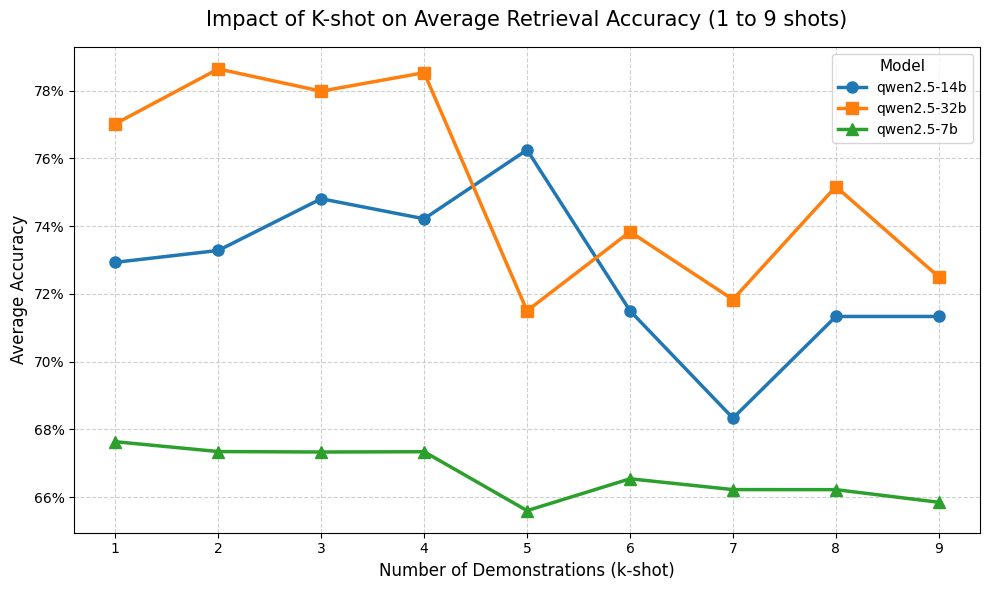

✅ 折线图已绘制完毕，并保存至: ./tmp/mlp/ablation/kshot_scaling_behavior.png


In [8]:
analyze_and_plot_kshot('./tmp/mlp/ablation')